# Japan Day Düsseldorf — Mobile Network Analysis

**Requirements:** `pandas`, `numpy`, `scipy`, `matplotlib`, `cartopy`

## 1. Get the data

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None, "display.precision", 3)

TRACE_FILES = {
    "Telekom": {
        "12-13": "data/clean/Telekom/12-13.csv",
        "15-16": "data/clean/Telekom/15-16.csv",
        "18-19": "data/clean/Telekom/18-19-and-speed.csv",
        "baseline": "data/clean/Telekom/baseline.csv",
        "baseline-speed": "data/clean/Telekom/baseline-and-speed.csv",
    },
    "O2": {
        "12-13": "data/clean/O2/12-13.csv",
        "15-16": "data/clean/O2/15-16.csv",
        "18-19": "data/clean/O2/18-19-and-speed.csv",
        "baseline": "data/clean/O2/baseline.csv",
        "baseline-speed": "data/clean/O2/baseline-and-speed.csv",
    },
}
EVENT_SLOTS = ["12-13", "15-16", "18-19"]
BASELINE_SLOTS = ["baseline", "baseline-speed"]

frames = []
for provider in TRACE_FILES:
    for slot in TRACE_FILES[provider]:
        df = pd.read_csv(TRACE_FILES[provider][slot])
        df["provider"] = provider
        df["slot"] = slot
        df["phase"] = "event" if slot in EVENT_SLOTS else "baseline"
        frames.append(df)

all_traces = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(all_traces)} rows total")
all_traces.groupby(["provider", "slot", "phase"]).size()

Loaded 39653 rows total


provider  slot            phase   
O2        12-13           event       3673
          15-16           event       3984
          18-19           event       6462
          baseline        baseline    2708
          baseline-speed  baseline    3575
Telekom   12-13           event       2655
          15-16           event       3954
          18-19           event       5006
          baseline        baseline    3002
          baseline-speed  baseline    4634
dtype: int64

## 2. Prepare data — combine Event and Baseline

We keep only `connectionStatus == "PRIMARY"` rows.

**Event** = all three Japan Day loops (`12-13`, `15-16`, `18-19-and-speed`) **pooled together** into one distribution (concatenated, not averaged — every individual measurement counts as one point).

**Baseline** = both quiet-day loops (`baseline`, `baseline-and-speed`) pooled the same way.

In [15]:
prim = all_traces[all_traces.connectionStatus == "PRIMARY"].copy()
print(prim)

groups = {}
for p in ["Telekom", "O2"]:
    for ph in ["event", "baseline"]:
        groups[(p, ph)] = prim[(prim.provider == p) & (prim.phase == ph)]

prim.groupby(["provider", "phase"]).size()

          id  scanId      timestamp  sampleIndex  latitude  longitude  \
0      14514       8  1779530957108            0       NaN        NaN   
4      14518       8  1779530959225            1    51.236      6.770   
8      14522       8  1779530961356            2    51.237      6.770   
12     14526       8  1779530963456            3    51.237      6.770   
16     14530       8  1779530965579            4    51.237      6.770   
...      ...     ...            ...          ...       ...        ...   
39611  49893      17  1782047099249          854    51.220      6.765   
39619  49901      17  1782047101787          855    51.220      6.765   
39631  49913      17  1782047104088          856    51.220      6.765   
39639  49921      17  1782047106484          857    51.220      6.765   
39647  49929      17  1782047108689          858    51.220      6.765   

       gpsAccuracy  altitude  speed technology    mcc  mnc    plmn  \
0              NaN       NaN    NaN        LTE  262.0

provider  phase   
O2        baseline    1579
          event       3049
Telekom   baseline    1726
          event       3136
dtype: int64

## 3. Boxplots — RSRP, RSRQ, SINR

Event vs. Baseline, Telekom vs. O2. Brackets show the Mann-Whitney significance level (*** p<0.001, ** p<0.01, * p<0.05, n.s. not significant)

In [16]:
TELEKOM = "#E20074"
TELEKOM_LIGHT = "#F6B8D9"
O2 = "#0050FF"
O2_LIGHT = "#AFC6FF"
INK = "#1A1A1A"
GRID = "#D8D5CC"

def mwu_p(a, b):
    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return p

def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "n.s."

def plot_boxplot(metric, ylabel):
    fig, ax = plt.subplots(figsize=(7, 5))
    data = [
        groups[("Telekom", "event")][metric].dropna().values,
        groups[("Telekom", "baseline")][metric].dropna().values,
        groups[("O2", "event")][metric].dropna().values,
        groups[("O2", "baseline")][metric].dropna().values,
    ]
    positions = [1, 2, 3.4, 4.4]
    colors = [TELEKOM, TELEKOM_LIGHT, O2, O2_LIGHT]

    bp = ax.boxplot(data, positions=positions, widths=0.75, patch_artist=True,
                     showfliers=False, medianprops=dict(color=INK, linewidth=1.6),
                     whiskerprops=dict(color=INK, linewidth=1.0),
                     capprops=dict(color=INK, linewidth=1.0),
                     boxprops=dict(linewidth=1.0, edgecolor=INK))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.92)

    rng = np.random.default_rng(42)
    for pos, arr, c in zip(positions, data, colors):
        arr_s = arr if len(arr) <= 250 else arr[rng.choice(len(arr), 250, replace=False)]
        jitter = rng.uniform(-0.18, 0.18, size=len(arr_s))
        ax.scatter(pos + jitter, arr_s, s=4, color=INK, alpha=0.12, zorder=1, linewidths=0)

    ax.set_xticks(positions)
    ax.set_xticklabels(["Event", "Baseline", "Event", "Baseline"], fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", color=GRID, linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.text(1.5, -0.12, "Telekom", transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=11, fontweight="bold", color=TELEKOM)
    ax.text(3.9, -0.12, "O2", transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=11, fontweight="bold", color=O2)

    e_tel = groups[("Telekom","event")][metric].dropna()
    b_tel = groups[("Telekom","baseline")][metric].dropna()
    e_o2 = groups[("O2","event")][metric].dropna()
    b_o2 = groups[("O2","baseline")][metric].dropna()
    p_tel, p_o2 = mwu_p(e_tel, b_tel), mwu_p(e_o2, b_o2)

    ymax = max(np.percentile(d, 97) for d in data)
    ymin = min(np.percentile(d, 3) for d in data)
    yspan = ymax - ymin
    y_bracket = ymax + yspan * 0.10
    h = yspan * 0.045

    for (x1, x2), p in [((1, 2), p_tel), ((3.4, 4.4), p_o2)]:
        ax.plot([x1, x1, x2, x2], [y_bracket, y_bracket+h, y_bracket+h, y_bracket], color=INK, linewidth=0.9)
        ax.text((x1+x2)/2, y_bracket+h*1.3, sig_stars(p), ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.set_ylim(ymin - yspan*0.08, y_bracket + yspan*0.28)
    ax.set_xlim(0.3, 5.1)
    ax.set_title(f"{ylabel.split(' (')[0]} — Event vs. Baseline", fontsize=13)
    plt.tight_layout()
    plt.show()
    return fig

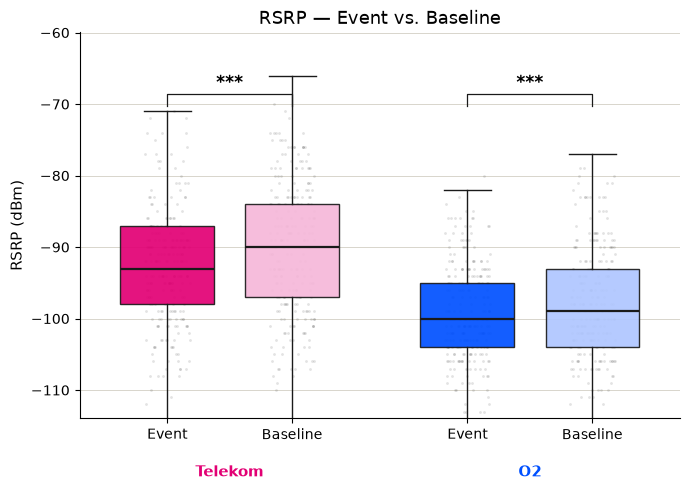

In [21]:
plot_boxplot("rsrp", "RSRP (dBm)");

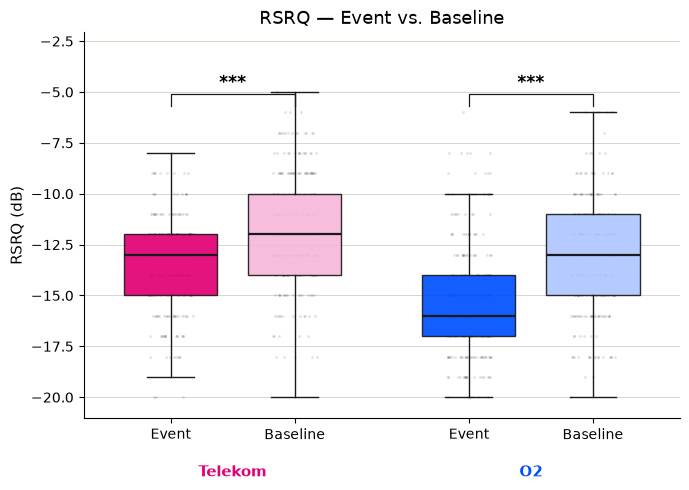

In [ ]:
plot_boxplot("rsrq", "RSRQ (dB)");

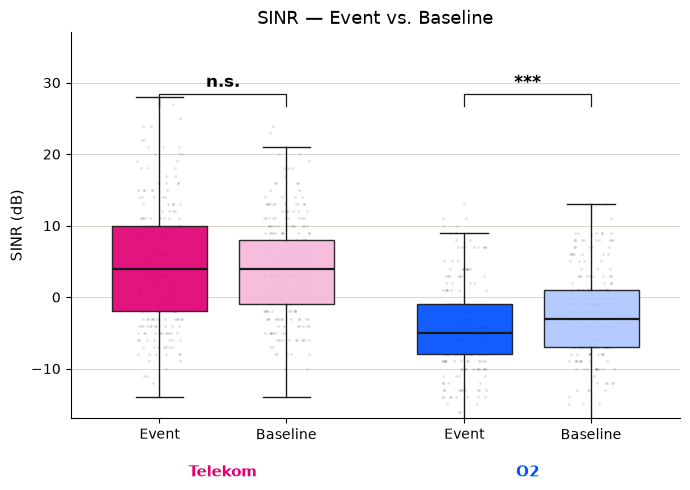

In [ ]:
plot_boxplot("sinr", "SINR (dB)");

## 4. RSRQ map — Telekom (15-16 vs. baseline)

Large circles = event (15-16 slot), large triangles = baseline, offset apart for visibility, colored by RSRQ.

In [22]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.colors as mcolors

# Projection hack, may not be needed on your cartopy version
WGS84_SEMIMAJOR_AXIS = 6378137
PC = ccrs.PlateCarree(
    globe=ccrs.Globe(
        ellipse="sphere",
        semimajor_axis=WGS84_SEMIMAJOR_AXIS,
        semiminor_axis=WGS84_SEMIMAJOR_AXIS,
    )
)

class _CartoVoyager(cimgt.GoogleWTS):
    def _image_url(self, tile):
        x, y, z = tile
        return f"https://basemaps.cartocdn.com/rastertiles/voyager/{z}/{x}/{y}.png"

ZOOM_LEVEL = 15
LON_OFFSET = 0.00035    # ~26m at this latitude -- event west, baseline east
MARKER_SIZE = 38         # large circles/triangles for A4 print legibility
MARKER_EDGE_WIDTH = 0.05  # near-invisible outline
TILE_CACHE = "~/.cache/cartopy/tiles"

# bounding box to drop GPS glitches (one known outlier ~9km off-route exists in O2 data)
LAT_MIN, LAT_MAX = 51.215, 51.242
LON_MIN, LON_MAX = 6.760, 6.776

def load_clean_for_map(path):
    df = pd.read_csv(path, dtype={"enb": str})
    df = df.dropna(subset=["latitude", "longitude"])
    df = df[df.connectionStatus == "PRIMARY"]
    df = df[df.latitude.between(LAT_MIN, LAT_MAX) & df.longitude.between(LON_MIN, LON_MAX)]
    return df

rsrq_event = load_clean_for_map(TRACE_FILES["Telekom"]["15-16"])
rsrq_baseline = load_clean_for_map(TRACE_FILES["Telekom"]["baseline"])
print(f"Event rows: {len(rsrq_event)}   Baseline rows: {len(rsrq_baseline)}")

Event rows: 987   Baseline rows: 778


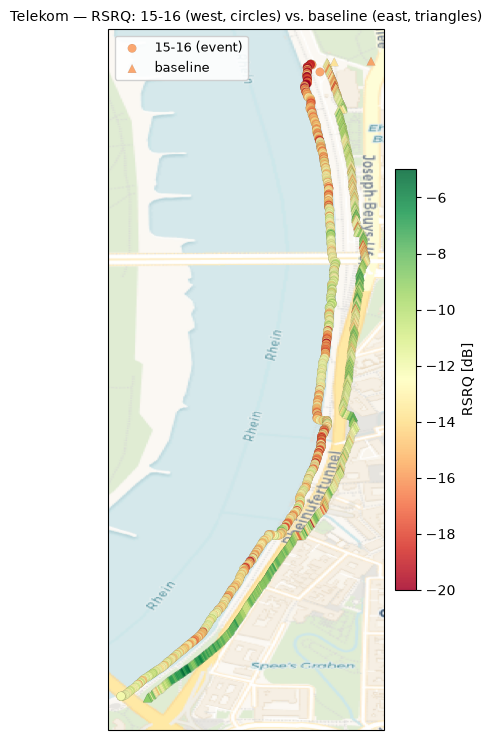

In [23]:
fig, ax = plt.subplots(figsize=(6, 7.5), subplot_kw=dict(projection=PC))
ax.add_image(_CartoVoyager(cache=TILE_CACHE), ZOOM_LEVEL)

vmin = min(rsrq_event.rsrq.min(), rsrq_baseline.rsrq.min())
vmax = max(rsrq_event.rsrq.max(), rsrq_baseline.rsrq.max())
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

sc1 = ax.scatter(
    rsrq_event.longitude - LON_OFFSET, rsrq_event.latitude,
    c=rsrq_event.rsrq, cmap="RdYlGn", norm=norm,
    s=MARKER_SIZE, alpha=0.85, transform=PC,
    edgecolors="black", linewidths=MARKER_EDGE_WIDTH,
    marker="o", label="15-16 (event)",
)
ax.scatter(
    rsrq_baseline.longitude + LON_OFFSET, rsrq_baseline.latitude,
    c=rsrq_baseline.rsrq, cmap="RdYlGn", norm=norm,
    s=MARKER_SIZE, alpha=0.85, transform=PC,
    edgecolors="black", linewidths=MARKER_EDGE_WIDTH,
    marker="^", label="baseline",
)

cbar = plt.colorbar(sc1, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("RSRQ [dB]", fontsize=10)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.set_title("Telekom — RSRQ: 15-16 (west, circles) vs. baseline (east, triangles)", fontsize=10)
plt.tight_layout()
plt.show()

## 5. Summary statistics — n and mean (RSRP, RSRQ, SINR)

Pooled Event vs. pooled Baseline, both providers. Mean values only.

In [24]:
summary_rows = []
for p in ["Telekom", "O2"]:
    for phase in ["event", "baseline"]:
        d = prim[(prim.provider == p) & (prim.phase == phase)]
        row = {"provider": p, "phase": phase, "n": len(d)}
        for metric in ["rsrp", "rsrq", "sinr"]:
            s = d[metric].dropna()
            row[f"{metric}_mean"] = round(s.mean(), 2)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

,provider,phase,n,rsrp_mean,rsrq_mean,sinr_mean
0,Telekom,event,3136,-92.39,-13.37,4.59
1,Telekom,baseline,1726,-90.44,-11.86,3.74
2,O2,event,3049,-99.57,-15.43,-4.23
3,O2,baseline,1579,-98.39,-13.25,-2.85


## 6. Handover rate across the day

Handover = serving-cell (`cid`) change between consecutive `PRIMARY` scans, detected separately within each loop (never across loop boundaries). 

Rate = handovers per minute. Significance stars, tested per event slot against the combined baseline using a two-sided binomial rate-ratio test.

In [25]:
def handover_rate(df_primary):
    d = df_primary.sort_values("timestamp")
    if len(d) < 2:
        return 0, 0, np.nan, d["cid"].nunique()
    changed = d["cid"].ne(d["cid"].shift())
    n_handovers = int(changed.sum() - 1)
    duration_min = (d["timestamp"].max() - d["timestamp"].min()) / 1000 / 60
    rate = n_handovers / duration_min if duration_min > 0 else np.nan
    return n_handovers, duration_min, rate, d["cid"].nunique()

ho_rows = []
for p in ["Telekom", "O2"]:
    for slot in EVENT_SLOTS + BASELINE_SLOTS:
        d = prim[(prim.provider == p) & (prim.slot == slot)]
        n_ho, dur, rate, n_cid = handover_rate(d)
        ho_rows.append(dict(provider=p, slot=slot, n_handovers=n_ho, duration_min=dur, rate=rate))
ho_df = pd.DataFrame(ho_rows)
ho_df

,provider,slot,n_handovers,duration_min,rate
0,Telekom,12-13,81,29.269,2.767
1,Telekom,15-16,98,34.642,2.829
2,Telekom,18-19,116,46.412,2.499
3,Telekom,baseline,58,26.991,2.149
4,Telekom,baseline-speed,81,33.596,2.411
5,O2,12-13,84,29.245,2.872
6,O2,15-16,125,34.625,3.610
7,O2,18-19,251,46.402,5.409
8,O2,baseline,72,27.007,2.666
9,O2,baseline-speed,82,33.577,2.442


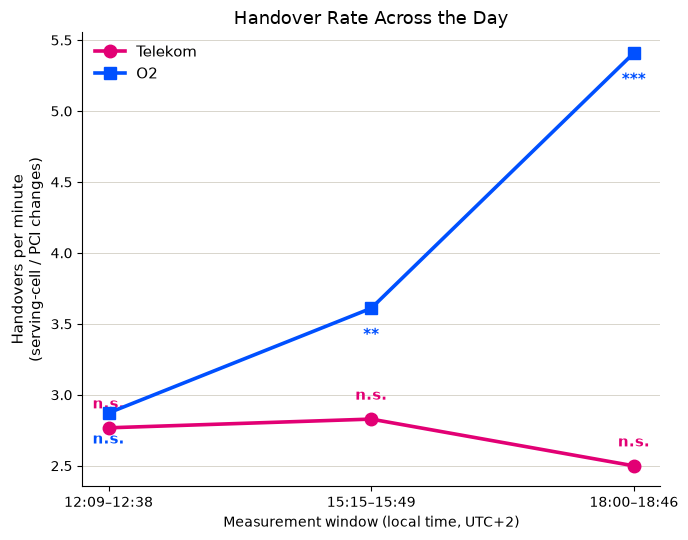

In [26]:
def poisson_rate_test(n1, t1, n2, t2):
    n_total = n1 + n2
    p0 = t1 / (t1 + t2)
    res = stats.binomtest(n1, n_total, p0, alternative="two-sided")
    return res.pvalue

slot_order = ["12-13", "15-16", "18-19"]
slot_labels = ["12:09\u201312:38", "15:15\u201315:49", "18:00\u201318:46"]  # local time, UTC+2 (CEST)

sig_vs_baseline = {}
for p in ["Telekom", "O2"]:
    base_sub = ho_df[(ho_df.provider == p) & (ho_df.slot.isin(BASELINE_SLOTS))]
    n2 = base_sub["n_handovers"].sum()
    t2 = base_sub["duration_min"].sum()
    for slot in slot_order:
        row = ho_df[(ho_df.provider == p) & (ho_df.slot == slot)].iloc[0]
        sig_vs_baseline[(p, slot)] = poisson_rate_test(row["n_handovers"], row["duration_min"], n2, t2)

fig, ax = plt.subplots(figsize=(7, 5.5))
x = np.arange(len(slot_order))
for p, color, marker, y_off in [("Telekom", TELEKOM, "o", 14), ("O2", O2, "s", -22)]:
    rates = [ho_df[(ho_df.provider == p) & (ho_df.slot == s)]["rate"].iloc[0] for s in slot_order]
    ax.plot(x, rates, color=color, marker=marker, markersize=9, linewidth=2.6, zorder=3, label=p)
    for xi, r, s in zip(x, rates, slot_order):
        ax.annotate(sig_stars(sig_vs_baseline[(p, s)]), (xi, r), textcoords="offset points",
                     xytext=(0, y_off), ha="center", fontsize=11, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(slot_labels, fontsize=10)
ax.set_xlabel("Measurement window (local time, UTC+2)", fontsize=10)
ax.set_ylabel("Handovers per minute\n(serving-cell / PCI changes)", fontsize=10.5)
ax.grid(axis="y", color=GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper left", frameon=False, fontsize=10.5)
ax.set_title("Handover Rate Across the Day", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Handover locations

Plots WHERE handovers happen along the route. Default shown: O2, 18-19 (event, the busiest slot) vs. its matching baseline-and-speed file. 

Change `PROVIDER`/`SLOT` below to view other combinations.

In [28]:
PROVIDER = "O2"
SLOT = "18-19"

# each event slot pairs with its own matching baseline file
# (12-13/15-16 -> baseline.csv;  18-19-and-speed -> baseline-and-speed.csv)
baseline_file_for_slot = {
    "12-13": TRACE_FILES[PROVIDER]["baseline"],
    "15-16": TRACE_FILES[PROVIDER]["baseline"],
    "18-19": TRACE_FILES[PROVIDER]["baseline-speed"],
}

def handover_locations(path):
    df = load_clean_for_map(path)
    df = df.sort_values("timestamp")
    changed = df["cid"].ne(df["cid"].shift())
    return df[changed].iloc[1:]  # drop first row (not a real handover)

event_ho = handover_locations(TRACE_FILES[PROVIDER][SLOT])
baseline_ho = handover_locations(baseline_file_for_slot[SLOT])
baseline_label = "baseline-and-speed" if SLOT == "18-19" else "baseline"

print(f"[{PROVIDER} {SLOT}] event handovers={len(event_ho)}  {baseline_label} handovers={len(baseline_ho)}")

[O2 18-19] event handovers=251  baseline-and-speed handovers=82


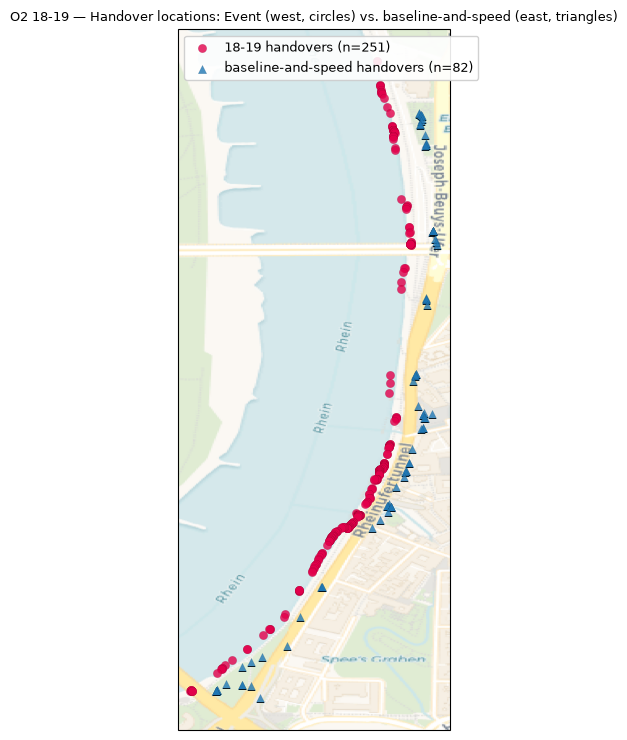

In [29]:
EVENT_COLOR = "#E2004B"
BASELINE_COLOR = "#1F77B4"

fig, ax = plt.subplots(figsize=(6, 7.5), subplot_kw=dict(projection=PC))
ax.add_image(_CartoVoyager(cache=TILE_CACHE), ZOOM_LEVEL)

ax.scatter(
    event_ho.longitude - LON_OFFSET, event_ho.latitude,
    c=EVENT_COLOR, s=MARKER_SIZE, alpha=0.8, transform=PC,
    edgecolors="black", linewidths=MARKER_EDGE_WIDTH,
    marker="o", label=f"{SLOT} handovers (n={len(event_ho)})",
)
ax.scatter(
    baseline_ho.longitude + LON_OFFSET, baseline_ho.latitude,
    c=BASELINE_COLOR, s=MARKER_SIZE, alpha=0.8, transform=PC,
    edgecolors="black", linewidths=MARKER_EDGE_WIDTH,
    marker="^", label=f"{baseline_label} handovers (n={len(baseline_ho)})",
)

ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.set_title(f"{PROVIDER} {SLOT} \u2014 Handover locations: Event (west, circles) vs. {baseline_label} (east, triangles)", fontsize=9.5)
plt.tight_layout()
plt.show()

## 8. Telekom speedtest — 18-19 (event) vs. baseline

Bars paired by stop/location order (rows in both files are already in matching location order — same route, same stops), so each stop's event and baseline bar sit right next to each other.

Telekom is used here because it's the only provider with a **consistent speedtest server** across event and baseline (O2 used different servers, so its absolute throughput isn't directly comparable).

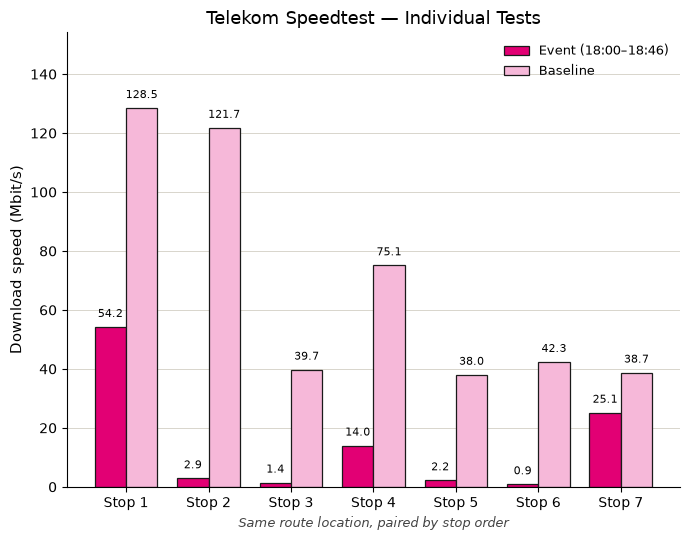

In [30]:
SPEED_COLS = ['Datum','VerbTyp','Lat','Lon','DL_Mbps','BytesDL','UL_Mbps','BytesUL',
              'Latency','Server','IntIP','ExtIP','URL']

tel_test = pd.read_csv("data/clean/Speedtest/Telekom-test.csv", header=0, names=SPEED_COLS)
tel_base = pd.read_csv("data/clean/Speedtest/Telekom-baseline.csv", header=0, names=SPEED_COLS)

event_dl = tel_test["DL_Mbps"].tolist()
baseline_dl = tel_base["DL_Mbps"].tolist()
n = min(len(event_dl), len(baseline_dl))

fig, ax = plt.subplots(figsize=(7, 5.5))
x = np.arange(n)
width = 0.38

ax.bar(x - width/2, event_dl[:n], width=width, color=TELEKOM, edgecolor=INK, linewidth=0.9, label="Event (18:00\u201318:46)")
ax.bar(x + width/2, baseline_dl[:n], width=width, color=TELEKOM_LIGHT, edgecolor=INK, linewidth=0.9, label="Baseline")

for xi, v in zip(x, event_dl[:n]):
    ax.text(xi - width/2, v + 2.5, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
for xi, v in zip(x, baseline_dl[:n]):
    ax.text(xi + width/2, v + 2.5, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"Stop {i+1}" for i in range(n)], fontsize=10)
ax.set_ylabel("Download speed (Mbit/s)", fontsize=10.5)
ax.set_ylim(0, max(baseline_dl) * 1.2)
ax.grid(axis="y", color=GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_xlabel("Same route location, paired by stop order", fontsize=9, style="italic", color="#444444")
ax.set_title("Telekom Speedtest \u2014 Individual Tests", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Final mean throughput — Telekom

Mean, standard deviation, and median for download and upload, event vs. baseline.

In [31]:
throughput_rows = []
for label, d in [("Event", tel_test), ("Baseline", tel_base)]:
    row = {"condition": label, "n": len(d)}
    for col, name in [("DL_Mbps", "DL"), ("UL_Mbps", "UL")]:
        row[f"{name}_mean"] = round(d[col].mean(), 1)
        row[f"{name}_std"] = round(d[col].std(), 1)
        row[f"{name}_median"] = round(d[col].median(), 1)
    throughput_rows.append(row)

throughput_df = pd.DataFrame(throughput_rows)
print("All values in Mbit/s")
throughput_df

All values in Mbit/s


,condition,n,DL_mean,DL_std,DL_median,UL_mean,UL_std,UL_median
0,Event,7,14.4,19.7,2.9,5.0,5.3,3.0
1,Baseline,7,69.2,40.4,42.3,20.3,14.6,19.7


In [32]:
u, p_dl = stats.mannwhitneyu(tel_test.DL_Mbps, tel_base.DL_Mbps, alternative="two-sided")
drop_ratio = tel_base.DL_Mbps.mean() / tel_test.DL_Mbps.mean()
print(f"Download throughput drop: \u00d7{drop_ratio:.1f}  (Mann-Whitney U, p={p_dl:.4f})")

Download throughput drop: ×4.8  (Mann-Whitney U, p=0.0070)
